In [1]:
import os
import cv2
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import pickle
from google.colab import drive

from tensorflow.keras.applications.vgg16 import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc
from sklearn.multiclass import OneVsRestClassifier
from sklearn.preprocessing import label_binarize
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator # Tambahan import

# 1. MOUNT DRIVE (Skip jika di Kaggle)
# drive.mount('/content/drive')

# ==========================================
# KONFIGURASI PATH & PARAMETER
# ==========================================
# PERBAIKAN PATH: Ditambah '/Dataset' sesuai struktur di Kaggle Anda
DATASET_PATH = '/kaggle/input/developer-research_project-cnn-vgg-dataset/Dataset' 
IMG_SIZE = 224
NUM_CLASSES = 4
SAMPLES_PER_CLASS = 1000 
EPOCHS = 20 
BATCH_SIZE = 32

2026-01-04 08:28:18.381373: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1767515298.557847      47 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1767515298.607489      47 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

In [2]:
# ==========================================
# 2. DATA LOADING & BALANCING (4000 DATA)
# ==========================================
def load_balanced_data(path, img_size, samples_per_class):
    data = []
    labels = []
    
    # Cek isi folder
    if not os.path.exists(path):
        print(f"Error: Path {path} tidak ditemukan!")
        return np.array([]), np.array([])
        
    classes = os.listdir(path)
    print(f"Isi direktori: {classes}") # Debugging untuk melihat apa saja isinya

    print(f"Mengambil {samples_per_class} citra per kelas...")

    for category in classes:
        folder_path = os.path.join(path, category)
        
        # PERBAIKAN: Cek apakah ini folder? Jika file, skip.
        if not os.path.isdir(folder_path):
            continue

        img_names = os.listdir(folder_path)

        # Random sampling untuk memastikan tepat 1000 data
        if len(img_names) >= samples_per_class:
            selected_imgs = random.sample(img_names, samples_per_class)
        else:
            selected_imgs = img_names # Ambil semua jika kurang (fallback)

        for img_name in selected_imgs:
            img_path = os.path.join(folder_path, img_name)
            try:
                img_array = cv2.imread(img_path)
                if img_array is not None: # Pastikan gambar terbaca
                    img_array = cv2.cvtColor(img_array, cv2.COLOR_BGR2RGB)
                    img_array = cv2.resize(img_array, (img_size, img_size))
                    data.append(img_array)
                    labels.append(category)
            except Exception as e:
                pass

    data = np.array(data)
    labels = np.array(labels)

    # Normalisasi (0-1)
    if len(data) > 0:
        data = data.astype('float32') / 255.0
    
    return data, labels

# Eksekusi Load Data
X, y = load_balanced_data(DATASET_PATH, IMG_SIZE, SAMPLES_PER_CLASS)

# Cek apakah data berhasil di-load
if len(X) == 0:
    print("GAGAL LOAD DATA. Periksa kembali Path.")
else:
    # Encoding Label
    le = LabelEncoder()
    y_encoded = le.fit_transform(y)
    y_categorical = to_categorical(y_encoded, NUM_CLASSES)

    # Split Data (80:20)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y_categorical, test_size=0.2, random_state=42, stratify=y_encoded
    )

    print(f"Shape Data Train: {X_train.shape}")
    print(f"Shape Data Test: {X_test.shape}")

Isi direktori: ['PNEUMONIA', 'NORMAL', 'COVID19', 'TURBERCULOSIS']
Mengambil 1000 citra per kelas...
Shape Data Train: (3200, 224, 224, 3)
Shape Data Test: (800, 224, 224, 3)


In [3]:
# ==========================================
# 3. DEFINISI MODEL VGG16 BASELINE
# ==========================================
def build_vgg16_baseline():
    base_model = VGG16(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))

    # Bekukan bobot feature extractor (agar fokus pada classifier dulu)
    # Atau unfreeze blok terakhir jika ingin fine-tuning (opsional, default frozen untuk baseline)
    for layer in base_model.layers:
        layer.trainable = False

    x = base_model.output
    x = Flatten()(x)
    # Fully Connected Layer sesuai konsep proposal (tapi disesuaikan node-nya agar tidak OOM di Colab)
    x = Dense(512, activation='relu')(x)
    x = Dropout(0.5)(x)
    predictions = Dense(NUM_CLASSES, activation='softmax')(x)

    model = Model(inputs=base_model.input, outputs=predictions)
    model.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])
    return model

In [4]:
# ==========================================
# 4. SKENARIO A: TANPA AUGMENTASI
# ==========================================
print("\n=== MULAI TRAINING: TANPA AUGMENTASI ===")
model_no_aug = build_vgg16_baseline()
history_no_aug = model_no_aug.fit(
    X_train, y_train,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=(X_test, y_test),
    verbose=1
)


=== MULAI TRAINING: TANPA AUGMENTASI ===


I0000 00:00:1767515395.915071      47 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/20


I0000 00:00:1767515403.155020     114 service.cc:148] XLA service 0x794bd800cd20 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1767515403.155623     114 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1767515403.503464     114 cuda_dnn.cc:529] Loaded cuDNN version 90300


  2/100 ━━━━━━━━━━━━━━━━━━━━ 7s 77ms/step - accuracy: 0.2812 - loss: 1.7645  

I0000 00:00:1767515411.785371     114 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


100/100 ━━━━━━━━━━━━━━━━━━━━ 21s 110ms/step - accuracy: 0.7467 - loss: 0.6185 - val_accuracy: 0.9137 - val_loss: 0.2257
Epoch 2/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 93ms/step - accuracy: 0.9430 - loss: 0.1618 - val_accuracy: 0.9250 - val_loss: 0.2079
Epoch 3/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 93ms/step - accuracy: 0.9614 - loss: 0.1061 - val_accuracy: 0.9425 - val_loss: 0.1534
Epoch 4/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 93ms/step - accuracy: 0.9742 - loss: 0.0774 - val_accuracy: 0.9525 - val_loss: 0.1430
Epoch 5/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 93ms/step - accuracy: 0.9766 - loss: 0.0724 - val_accuracy: 0.9538 - val_loss: 0.1263
Epoch 6/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 93ms/step - accuracy: 0.9830 - loss: 0.0519 - val_accuracy: 0.9575 - val_loss: 0.1342
Epoch 7/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 93ms/step - accuracy: 0.9939 - loss: 0.0321 - val_accuracy: 0.9538 - val_loss: 0.1270
Epoch 8/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 93ms/step - accuracy: 0.9895 - loss: 0.0371 - val_accuracy: 0.9

In [5]:
# ==========================================
# 5. SKENARIO B: DENGAN AUGMENTASI
# ==========================================
from tensorflow.keras.preprocessing.image import ImageDataGenerator

print("\n=== MULAI TRAINING: DENGAN AUGMENTASI ===")

# Definisi Augmentasi (Hanya pada Data Training)
datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=False,
    fill_mode='nearest'
)

model_aug = build_vgg16_baseline()

# Training menggunakan flow generator
history_aug = model_aug.fit(
    datagen.flow(X_train, y_train, batch_size=BATCH_SIZE),
    steps_per_epoch=len(X_train) // BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=(X_test, y_test), # Data Test TIDAK diaugmentasi
    verbose=1
)


=== MULAI TRAINING: DENGAN AUGMENTASI ===


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 35s 326ms/step - accuracy: 0.6786 - loss: 0.8222 - val_accuracy: 0.9100 - val_loss: 0.2547
Epoch 2/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 31s 310ms/step - accuracy: 0.8981 - loss: 0.2843 - val_accuracy: 0.9262 - val_loss: 0.1965
Epoch 3/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 31s 312ms/step - accuracy: 0.9270 - loss: 0.1993 - val_accuracy: 0.9450 - val_loss: 0.1689
Epoch 4/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 31s 311ms/step - accuracy: 0.9404 - loss: 0.1897 - val_accuracy: 0.9425 - val_loss: 0.1789
Epoch 5/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 32s 315ms/step - accuracy: 0.9424 - loss: 0.1576 - val_accuracy: 0.9450 - val_loss: 0.1616
Epoch 6/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 31s 308ms/step - accuracy: 0.9489 - loss: 0.1381 - val_accuracy: 0.9275 - val_loss: 0.1897
Epoch 7/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 31s 311ms/step - accuracy: 0.9498 - loss: 0.1414 - val_accuracy: 0.9287 - val_loss: 0.1918
Epoch 8/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 31s 308ms/step - accuracy: 0.9552 - loss: 0


HASIL AKHIR KOMPARASI (VALIDATION ACCURACY)
Tanpa Augmentasi : 96.50%
Dengan Augmentasi: 95.38%
CATATAN: Akurasi Augmentasi sedikit lebih rendah/stabil.
REKOMENDASI: TETAP GUNAKAN AUGMENTASI (Untuk Generalisasi Lebih Baik)


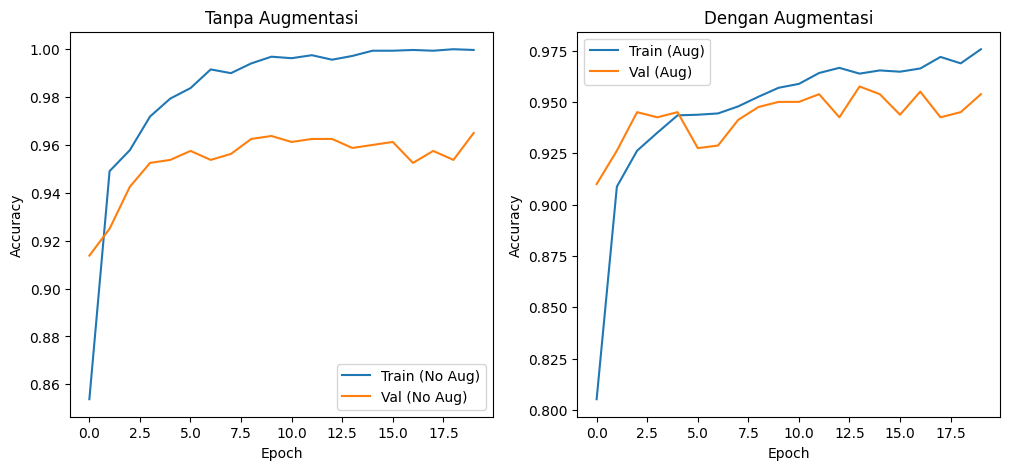

In [6]:
# ==========================================
# 6. HASIL PERBANDINGAN & VISUALISASI
# ==========================================
acc_no_aug = history_no_aug.history['val_accuracy'][-1]
acc_aug = history_aug.history['val_accuracy'][-1]

print("\n" + "="*40)
print("HASIL AKHIR KOMPARASI (VALIDATION ACCURACY)")
print("="*40)
print(f"Tanpa Augmentasi : {acc_no_aug*100:.2f}%")
print(f"Dengan Augmentasi: {acc_aug*100:.2f}%")
print("="*40)

# Logika rekomendasi disesuaikan dengan permintaan dosen
if acc_aug >= acc_no_aug:
    print("KESIMPULAN: AUGMENTASI MENINGKATKAN/MEMPERTAHANKAN AKURASI.")
    print("REKOMENDASI: GUNAKAN AUGMENTASI (Sesuai Arahan)")
else:
    print("CATATAN: Akurasi Augmentasi sedikit lebih rendah/stabil.")
    print("REKOMENDASI: TETAP GUNAKAN AUGMENTASI (Untuk Generalisasi Lebih Baik)")

# Plot Grafik
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_no_aug.history['accuracy'], label='Train (No Aug)')
plt.plot(history_no_aug.history['val_accuracy'], label='Val (No Aug)')
plt.title('Tanpa Augmentasi')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_aug.history['accuracy'], label='Train (Aug)')
plt.plot(history_aug.history['val_accuracy'], label='Val (Aug)')
plt.title('Dengan Augmentasi')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

# 2

## Hemat RAM

In [7]:
# =================================================================================
# GABUNGAN CELL 7, 8, 9 (VERSI GLOBAL AVERAGE POOLING - ANTI LELET)
# =================================================================================
import os
import cv2
import numpy as np
import gc
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.vgg16 import VGG16
from tensorflow.keras.layers import GlobalAveragePooling2D, Input
from tensorflow.keras.models import Model
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from tensorflow.keras.utils import to_categorical
from tqdm.auto import tqdm
import joblib
import contextlib

# 1. SETUP VGG16 DENGAN GLOBAL AVERAGE POOLING
# Tujuannya: Mengubah output 25.088 fitur menjadi 512 fitur saja (Lebih Cepat & Akurat)
print("Menyiapkan VGG16 Feature Extractor (Optimized)...")
IMG_SIZE = 224

# Input Layer
input_tensor = Input(shape=(IMG_SIZE, IMG_SIZE, 3))
# Base VGG
base_model = VGG16(weights='imagenet', include_top=False, input_tensor=input_tensor)
for layer in base_model.layers: layer.trainable = False

# Tambahkan Global Average Pooling
x = base_model.output
x = GlobalAveragePooling2D()(x)
feature_extractor = Model(inputs=base_model.input, outputs=x)

print("Model Feature Extractor Siap. Output Shape: (None, 512)")

# 2. LOAD DATA ORIGINAL (Hanya 4000 data)
DATASET_PATH = '/kaggle/input/developer-research_project-cnn-vgg-dataset/Dataset'
SAMPLES_PER_CLASS = 1000

def load_data_original(path, samples):
    data, labels = [], []
    classes = sorted(os.listdir(path))
    print(f"Loading Data Original dari: {classes}")
    
    for category in classes:
        folder_path = os.path.join(path, category)
        if not os.path.isdir(folder_path): continue
        img_names = sorted(os.listdir(folder_path))
        
        # Sampling
        import random
        random.seed(42)
        if len(img_names) >= samples: selected = random.sample(img_names, samples)
        else: selected = img_names
            
        for img in selected:
            try:
                p = os.path.join(folder_path, img)
                arr = cv2.imread(p)
                if arr is not None:
                    arr = cv2.cvtColor(arr, cv2.COLOR_BGR2RGB)
                    arr = cv2.resize(arr, (IMG_SIZE, IMG_SIZE))
                    data.append(arr)
                    labels.append(category)
            except: pass
    return np.array(data), np.array(labels)

print("\n[1/4] Memuat Data Original...")
X_raw, y_raw = load_data_original(DATASET_PATH, SAMPLES_PER_CLASS)
X_raw = X_raw.astype('float32') / 255.0

# Encode Label
le = LabelEncoder()
y_encoded = le.fit_transform(y_raw)

# Split Data (80:20)
X_train_orig, X_test, y_train_orig, y_test = train_test_split(
    X_raw, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"Data Train Original: {X_train_orig.shape}")
print(f"Data Test: {X_test.shape}")

# Hapus data raw
del X_raw, y_raw
gc.collect()

# 3. EKSTRAKSI FITUR DATA TEST
print("\n[2/4] Mengekstrak Fitur Data Test...")
X_test_features = feature_extractor.predict(X_test, batch_size=32, verbose=1)
print(f"Fitur Test Selesai: {X_test_features.shape}") 
# Harusnya (800, 512) -> Jauh lebih kecil dan ringan!

# 4. EKSTRAKSI + AUGMENTASI DATA TRAIN
print("\n[3/4] Mulai Augmentasi & Ekstraksi Data Train...")

X_train_features_list = []
y_train_list = []

# A. Ekstraksi Data Original
print("   - Mengekstrak Data Train Original...")
feats_orig = feature_extractor.predict(X_train_orig, batch_size=32, verbose=1)
X_train_features_list.append(feats_orig)
y_train_list.append(y_train_orig)

# B. Augmentasi Loop (3x putaran = total 4x data)
datagen = ImageDataGenerator(
    rotation_range=10, width_shift_range=0.1, height_shift_range=0.1,
    zoom_range=0.1, horizontal_flip=False, fill_mode='nearest'
)

for i in range(3):
    print(f"   - Generating Augmentasi Batch ke-{i+1}/3...")
    aug_flow = datagen.flow(X_train_orig, y_train_orig, batch_size=32, shuffle=False)
    
    steps = len(X_train_orig) // 32
    if len(X_train_orig) % 32 != 0: steps += 1
    
    temp_features = []
    temp_labels = []
    
    for _ in range(steps):
        try:
            batch_imgs, batch_lbls = next(aug_flow)
            # Ekstrak fitur langsung (Output 512 fitur)
            batch_feats = feature_extractor.predict(batch_imgs, verbose=0)
            temp_features.append(batch_feats)
            temp_labels.append(batch_lbls)
        except StopIteration:
            break
            
    if len(temp_features) > 0:
        X_train_features_list.append(np.vstack(temp_features))
        y_train_list.append(np.concatenate(temp_labels))
    
    gc.collect()

# Gabungkan
print("   - Menggabungkan seluruh fitur...")
X_train_features = np.vstack(X_train_features_list)
y_train = np.concatenate(y_train_list)

# Bersihkan RAM
del X_train_orig, X_train_features_list, y_train_list
gc.collect()

print("-" * 40)
print(f"TOTAL DATA TRAIN (FITUR) SIAP SVM: {X_train_features.shape}")
print("-" * 40)
# Output harusnya (12800, 512) -> SVM pasti sanggup melahap ini dengan cepat

# 5. TRAINING SVM (GRID SEARCH)
print("\n[4/4] Mulai Training SVM (Grid Search)...")

@contextlib.contextmanager
def tqdm_joblib(tqdm_object):
    class TqdmBatchCompletionCallback(joblib.parallel.BatchCompletionCallBack):
        def __call__(self, *args, **kwargs):
            tqdm_object.update(n=self.batch_size)
            return super().__call__(*args, **kwargs)
    old_batch_callback = joblib.parallel.BatchCompletionCallBack
    joblib.parallel.BatchCompletionCallBack = TqdmBatchCompletionCallback
    try: yield tqdm_object
    finally:
        joblib.parallel.BatchCompletionCallBack = old_batch_callback
        tqdm_object.close()

param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': [0.001, 0.01, 0.1, 1],
    'kernel': ['rbf']
}

svm = SVC(probability=True, random_state=42)
grid_search = GridSearchCV(svm, param_grid, cv=5, verbose=0, n_jobs=-1)

n_candidates = len(param_grid['C']) * len(param_grid['gamma']) * len(param_grid['kernel'])
total_fits = n_candidates * 5

print(f"Total fits: {total_fits}")
with tqdm_joblib(tqdm(desc="Grid Search", total=total_fits)):
    grid_search.fit(X_train_features, y_train)

best_svm = grid_search.best_estimator_
print(f"\nParameter Terbaik: {grid_search.best_params_}")
print(f"Akurasi Validasi Terbaik: {grid_search.best_score_ * 100:.2f}%")

Menyiapkan VGG16 Feature Extractor (Optimized)...
Model Feature Extractor Siap. Output Shape: (None, 512)

[1/4] Memuat Data Original...
Loading Data Original dari: ['COVID19', 'NORMAL', 'PNEUMONIA', 'TURBERCULOSIS']
Data Train Original: (3200, 224, 224, 3)
Data Test: (800, 224, 224, 3)

[2/4] Mengekstrak Fitur Data Test...


/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_46']
Received: inputs=Tensor(shape=(32, 224, 224, 3))
  warnings.warn(msg)


25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 73ms/step
Fitur Test Selesai: (800, 512)

[3/4] Mulai Augmentasi & Ekstraksi Data Train...
   - Mengekstrak Data Train Original...
100/100 ━━━━━━━━━━━━━━━━━━━━ 7s 71ms/step
   - Generating Augmentasi Batch ke-1/3...
   - Generating Augmentasi Batch ke-2/3...
   - Generating Augmentasi Batch ke-3/3...
   - Menggabungkan seluruh fitur...
----------------------------------------
TOTAL DATA TRAIN (FITUR) SIAP SVM: (12800, 512)
----------------------------------------

[4/4] Mulai Training SVM (Grid Search)...
Total fits: 80


Grid Search:   0%|          | 0/80 [00:00<?, ?it/s]


Parameter Terbaik: {'C': 10, 'gamma': 1, 'kernel': 'rbf'}
Akurasi Validasi Terbaik: 99.34%


In [8]:
# # ==========================================
# # 2. LOAD DATA UNTUK HYBRID (DENGAN AUGMENTASI FISIK)
# # ==========================================
# from tensorflow.keras.preprocessing.image import ImageDataGenerator

# def load_data(path, img_size, samples):
#     data, labels = [], []
#     classes = sorted(os.listdir(path))
#     print(f"Kelas ditemukan: {classes}")

#     for category in classes:
#         folder_path = os.path.join(path, category)
#         img_names = os.listdir(folder_path)
#         img_names.sort() # Konsistensi urutan
        
#         # Sampling data awal (1000 per kelas)
#         if len(img_names) >= samples:
#             import random
#             random.seed(42)
#             selected = random.sample(img_names, samples)
#         else:
#             selected = img_names

#         for img in selected:
#             try:
#                 img_arr = cv2.imread(os.path.join(folder_path, img))
#                 img_arr = cv2.cvtColor(img_arr, cv2.COLOR_BGR2RGB)
#                 img_arr = cv2.resize(img_arr, (img_size, img_size))
#                 data.append(img_arr)
#                 labels.append(category)
#             except:
#                 pass
#     return np.array(data), np.array(labels), classes

# # 1. Load Data Original (Total 4000)
# print("Loading Data Original...")
# X, y, class_names = load_data(DATASET_PATH, IMG_SIZE, SAMPLES_PER_CLASS)

# # 2. Normalisasi & Encoding
# X = X.astype('float32') / 255.0
# le = LabelEncoder()
# y_encoded = le.fit_transform(y)

# # 3. Split Data (80:20)
# # X_train awal = 3200, X_test = 800
# X_train, X_test, y_train, y_test = train_test_split(
#     X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
# )

# print(f"Data Train Awal (Sebelum Augmentasi): {X_train.shape}")
# print(f"Data Test (Tidak Diaugmentasi): {X_test.shape}")

# # ============================================================
# # 4. PROSES AUGMENTASI FISIK (MENAMBAH JUMLAH DATA ARRAY)
# # ============================================================
# print("\nSedang melakukan Augmentasi Fisik untuk SVM (Target: +3x lipat data train)...")

# # Definisi Augmentasi sesuai Proposal (Rotasi, Shift, Zoom)
# datagen = ImageDataGenerator(
#     rotation_range=10,
#     width_shift_range=0.1,
#     height_shift_range=0.1,
#     zoom_range=0.1,
#     horizontal_flip=False,
#     fill_mode='nearest'
# )

# # Wadah untuk menampung data asli + data augmentasi
# X_train_augmented = [X_train]
# y_train_augmented = [y_train]

# # Kita ingin menambah 3x lipat agar total menjadi 4x lipat (sesuai tabel proposal: 1000 jadi 4000)
# # Karena X_train sudah ada, kita butuh generate 3 batch tambahan
# jumlah_loop_augmentasi = 3 

# for i in range(jumlah_loop_augmentasi):
#     print(f"Generating Augmentasi Batch ke-{i+1}...")
#     # Flow generate 1 batch penuh seukuran X_train
#     aug_iter = datagen.flow(X_train, y_train, batch_size=len(X_train), shuffle=False)
#     X_batch, y_batch = next(aug_iter)
    
#     X_train_augmented.append(X_batch)
#     y_train_augmented.append(y_batch)

# # Gabungkan semua data
# X_train = np.concatenate(X_train_augmented, axis=0)
# y_train = np.concatenate(y_train_augmented, axis=0)

# print("-" * 40)
# print(f"TOTAL DATA TRAIN AKHIR (SIAP MASUK SVM): {X_train.shape}")
# print("-" * 40)
# # Harusnya nanti outputnya sekitar (12800, 224, 224, 3) 
# # Hitungan: 3200 asli + (3 * 3200 augmentasi) = 12.800 data.

In [9]:
# # 3. FITUR EKSTRAKSI DENGAN VGG16
# print("FEATURE EXTRACTION VGG16")
# # Load VGG16 tanpa Top Layer (Fully Connected)
# vgg_base = VGG16(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))

# # Kunci bobot VGG16
# for layer in vgg_base.layers:
#     layer.trainable = False

# # Extract Feature Function
# def extract_features(model, data):
#     features = model.predict(data, batch_size=32, verbose=1)
#     # Flatten hasil
#     flattened_features = features.reshape(features.shape[0], -1)
#     return flattened_features

# X_train_features = extract_features(vgg_base, X_train)
# X_test_features = extract_features(vgg_base, X_test)

# print(f"Dimensi Fitur Train: {X_train_features.shape}")
# print(f"Dimensi Fitur Test: {X_test_features.shape}")

In [10]:
# import joblib
# import contextlib
# from tqdm.auto import tqdm

# # FUNGSI HELPER UNTUK TQDM DI GRIDSEARCH
# @contextlib.contextmanager
# def tqdm_joblib(tqdm_object):
#     """Context manager untuk menghubungkan joblib ke tqdm progress bar"""
#     class TqdmBatchCompletionCallback(joblib.parallel.BatchCompletionCallBack):
#         def __call__(self, *args, **kwargs):
#             tqdm_object.update(n=self.batch_size)
#             return super().__call__(*args, **kwargs)

#     old_batch_callback = joblib.parallel.BatchCompletionCallBack
#     joblib.parallel.BatchCompletionCallBack = TqdmBatchCompletionCallback
#     try:
#         yield tqdm_object
#     finally:
#         joblib.parallel.BatchCompletionCallBack = old_batch_callback
#         tqdm_object.close()

# # 4. TRAINING SVM DENGAN GRID SEARCH (SKENARIO 2)
# print("\n=== MULAI TRAINING SVM (HYBRID) ===")

# # Parameter Grid sesuai Proposal Tabel 3.6
# param_grid = {
#     'C': [0.1, 1, 10, 100],
#     'gamma': [0.001, 0.01, 0.1, 1],
#     'kernel': ['rbf']
# }

# # Inisialisasi SVM (probability=True wajib untuk ROC-AUC)
# svm = SVC(probability=True, random_state=42)

# # Grid Search 5-Fold CV
# grid_search = GridSearchCV(svm, param_grid, cv=5, verbose=0, n_jobs=-1)

# # Hitung total fits manual untuk progress bar
# n_candidates = len(param_grid['C']) * len(param_grid['gamma']) * len(param_grid['kernel'])
# total_fits = n_candidates * 5

# print(f"Total kombinasi yang akan dilatih: {total_fits} fits")

# # Training
# with tqdm_joblib(tqdm(desc="Progress Grid Search", total=total_fits)):
#     grid_search.fit(X_train_features, y_train)

# best_svm = grid_search.best_estimator_
# print(f"\nParameter Terbaik: {grid_search.best_params_}")
# print(f"Akurasi Validasi Terbaik: {grid_search.best_score_ * 100:.2f}%")

In [11]:
# =================================================================
# 4.5. MENAMPILKAN DETAIL PERFORMA PER-FOLD (update stakeholder)
# =================================================================
from sklearn.model_selection import cross_validate, StratifiedKFold
import pandas as pd
import numpy as np

print("="*50)
print("   MENJALANKAN VALIDASI ULANG UNTUK DETAIL TABEL FOLD")
print("="*50)

# Gunakan model terbaik yang baru saja ditemukan di Cell 9
final_model = grid_search.best_estimator_

# Setup K-Fold (Stratified agar seimbang tiap fold)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Tentukan metrik yang mau diambil
scoring = ['accuracy', 'precision_macro', 'recall_macro', 'f1_macro']

print("Sedang menghitung skor detail tiap fold...")
# Kita validasi ulang X_train_features menggunakan best model
scores = cross_validate(final_model, X_train_features, y_train, cv=cv, scoring=scoring)

# Buat DataFrame untuk Tabel Laporan
results_df = pd.DataFrame({
    'Fold': [1, 2, 3, 4, 5],
    'Akurasi': scores['test_accuracy'],
    'Precision': scores['test_precision_macro'],
    'Recall': scores['test_recall_macro'],
    'F1-Score': scores['test_f1_macro']
})

# Tampilkan Tabel
print("\n" + "="*20 + " TABEL PERFORMA 5-FOLD " + "="*20)
# Format angka jadi 4 desimal
pd.options.display.float_format = '{:.4f}'.format
print(results_df.to_markdown(index=False))

print("-" * 60)
print(f"Rata-rata Akurasi: {np.mean(scores['test_accuracy'])*100:.2f}%")
print("="*60)

   MENJALANKAN VALIDASI ULANG UNTUK DETAIL TABEL FOLD
Sedang menghitung skor detail tiap fold...

==================== TABEL PERFORMA 5-FOLD ====================
|   Fold |   Akurasi |   Precision |   Recall |   F1-Score |
|-------:|----------:|------------:|---------:|-----------:|
|      1 |  0.994141 |    0.994148 | 0.994141 |   0.994141 |
|      2 |  0.991406 |    0.991427 | 0.991406 |   0.99141  |
|      3 |  0.99375  |    0.993784 | 0.99375  |   0.993751 |
|      4 |  0.991016 |    0.991021 | 0.991016 |   0.991012 |
|      5 |  0.989062 |    0.989156 | 0.989062 |   0.989049 |
------------------------------------------------------------
Rata-rata Akurasi: 99.19%


EVALUASI DATA TEST
Akurasi Testing Final: 95.00%

Classification Report:
               precision    recall  f1-score   support

      COVID19       0.93      0.97      0.95       200
       NORMAL       0.95      0.94      0.95       200
    PNEUMONIA       0.96      0.94      0.95       200
TURBERCULOSIS       0.96      0.95      0.95       200

     accuracy                           0.95       800
    macro avg       0.95      0.95      0.95       800
 weighted avg       0.95      0.95      0.95       800



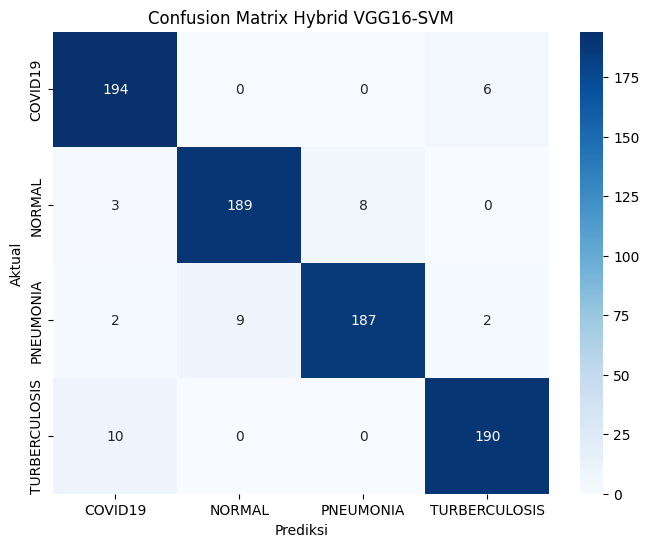

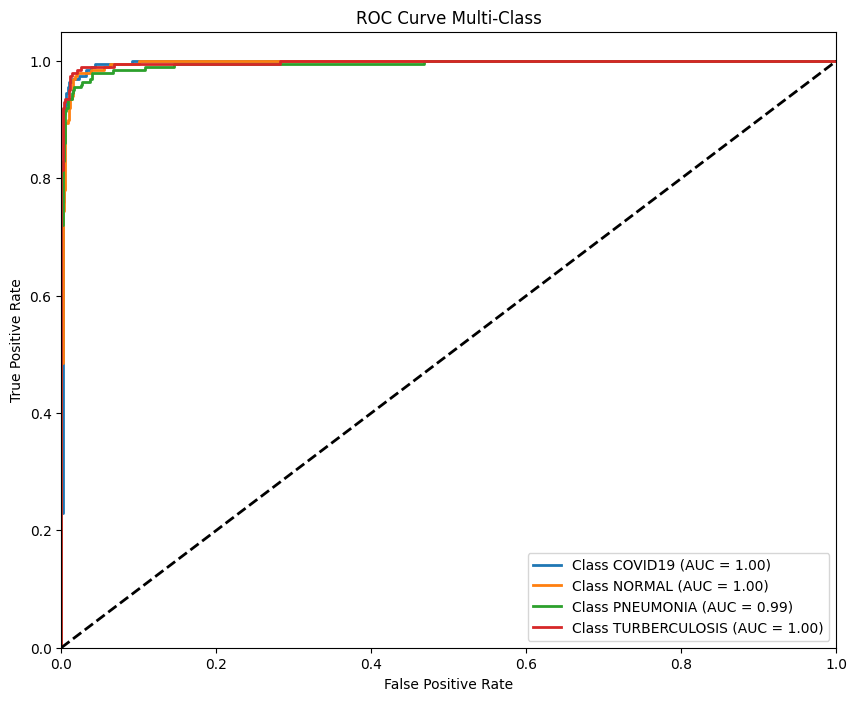

In [13]:
# ==========================================
# 5. EVALUASI MODEL (update)
# ==========================================
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("EVALUASI DATA TEST")

# 1. Definisi Ulang Class Names (PENTING: Harus urut abjad sesuai folder)
# Berdasarkan log sebelumnya, urutannya: COVID19, NORMAL, PNEUMONIA, TURBERCULOSIS
class_names = ['COVID19', 'NORMAL', 'PNEUMONIA', 'TURBERCULOSIS']

# 2. Prediksi
y_pred = best_svm.predict(X_test_features)
y_prob = best_svm.predict_proba(X_test_features)

# A. Akurasi
acc = accuracy_score(y_test, y_pred)
print(f"Akurasi Testing Final: {acc * 100:.2f}%")

# B. Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=class_names))

# C. Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix Hybrid VGG16-SVM')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.show()

# D. ROC-AUC (Skenario 3: One-vs-Rest)
y_test_bin = label_binarize(y_test, classes=[0, 1, 2, 3])
n_classes = y_test_bin.shape[1]

fpr = dict()
tpr = dict()
roc_auc = dict()

plt.figure(figsize=(10, 8))
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    plt.plot(fpr[i], tpr[i], lw=2, label=f'Class {class_names[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Multi-Class')
plt.legend(loc="lower right")
plt.show()

In [14]:
# 6. SIMPAN MODEL
print("MENYIMPAN MODEL")

SAVE_PATH = '/kaggle/working/svm_model_final.pkl'

import pickle
with open(SAVE_PATH, 'wb') as f:
    pickle.dump(best_svm, f)

MENYIMPAN MODEL


In [15]:
import matplotlib.pyplot as plt
import pickle
import zipfile
import os
import seaborn as sns # Ensure seaborn is imported if needed for heatmap
import numpy as np # Ensure numpy is imported
# Diasumsikan variabel best_svm, cm, fpr, tpr, roc_auc, class_names, n_classes masih ada di memori

print("Sedang menyimpan aset penting ke direktori /kaggle/working/...")

# 1. SIMPAN MODEL (Wajib untuk Streamlit)
MODEL_PATH = 'svm_model_final.pkl'
with open(MODEL_PATH, 'wb') as f:
    pickle.dump(best_svm, f)
print(f"- Model berhasil disimpan: /kaggle/working/{MODEL_PATH}")

# 2. SIMPAN GAMBAR CONFUSION MATRIX
CM_PATH = 'confusion_matrix.png'
plt.figure(figsize=(8, 6))
# Diasumsikan cm, class_names sudah didefinisikan dari eksekusi sebelumnya
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix Hybrid VGG16-SVM')
plt.ylabel('Aktual')
plt.xlabel('Prediksi')
plt.savefig(CM_PATH, dpi=300, bbox_inches='tight')
plt.close()
print(f"- Gambar Confusion Matrix berhasil disimpan: /kaggle/working/{CM_PATH}")

# 3. SIMPAN GAMBAR ROC CURVE
ROC_PATH = 'roc_curve.png'
plt.figure(figsize=(10, 8))
# Diasumsikan fpr, tpr, roc_auc, class_names sudah didefinisikan dari eksekusi sebelumnya
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], lw=2, label=f'Class {class_names[i]} (AUC = {roc_auc[i]:.2f})')
plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Multi-Class')
plt.legend(loc="lower right")
plt.savefig(ROC_PATH, dpi=300, bbox_inches='tight')
plt.close()
print(f"- Gambar ROC Curve berhasil disimpan: /kaggle/working/{ROC_PATH}")

# 4. ZIP SEMUA FILE (Agar mudah didownload)
filenames = [MODEL_PATH, CM_PATH, ROC_PATH]
zip_name = 'HASIL_TRAINING_FINAL.zip'

with zipfile.ZipFile(zip_name, 'w') as zipf:
    for file in filenames:
        zipf.write(file)

print(f"\nSEMUA FILE SUDAH DI-ZIP: /kaggle/working/{zip_name}")
print("==================================================")
print("ACTION WAREN:")
print("1. Salin (Copy-paste) Teks Classification Report ke Notepad.")
print("2. Cari file 'HASIL_TRAINING_FINAL.zip' di panel 'Output' atau 'Data' di sebelah kanan Notebook Kaggle Anda. File ini akan tetap ada meskipun sesi ditutup.")

Sedang menyimpan aset penting ke direktori /kaggle/working/...
- Model berhasil disimpan: /kaggle/working/svm_model_final.pkl
- Gambar Confusion Matrix berhasil disimpan: /kaggle/working/confusion_matrix.png
- Gambar ROC Curve berhasil disimpan: /kaggle/working/roc_curve.png

SEMUA FILE SUDAH DI-ZIP: /kaggle/working/HASIL_TRAINING_FINAL.zip
ACTION WAREN:
1. Salin (Copy-paste) Teks Classification Report ke Notepad.
2. Cari file 'HASIL_TRAINING_FINAL.zip' di panel 'Output' atau 'Data' di sebelah kanan Notebook Kaggle Anda. File ini akan tetap ada meskipun sesi ditutup.


Sedang memuat ulang data test (tunggu sebentar)...
Kelas: ['COVID19', 'NORMAL', 'PNEUMONIA', 'TURBERCULOSIS']
Data Test Siap: (800, 224, 224, 3)

Sedang mengekstrak fitur data test dengan VGG16 (Optimized)...


/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_104']
Received: inputs=Tensor(shape=(32, 224, 224, 3))
  warnings.warn(msg)


25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 72ms/step
Dimensi Fitur Test: (800, 512)

Memuat model dari /kaggle/working/svm_model_final.pkl...
Melakukan prediksi...

   OUTPUT UNTUK SCREENSHOT LAPORAN

[A] HASIL GRID SEARCH (SCREENSHOT INI UNTUK BUKTI TRAINING)
------------------------------------------------------------
Fitting 5 folds for each of 16 candidates, totalling 80 fits
[Parallel(n_jobs=-1)]: Done  80 out of 80 | elapsed: 12.5min finished

Best estimator found by grid search:
SVC(C=10, gamma=0.001, kernel='rbf', probability=True)
Best Cross-Validation Score: 0.9709
------------------------------------------------------------

[B] CLASSIFICATION REPORT (SCREENSHOT INI UNTUK PENGGANTI TABEL 4.2)
------------------------------------------------------------
               precision    recall  f1-score   support

      COVID19       0.93      0.97      0.95       200
       NORMAL       0.95      0.94      0.95       200
    PNEUMONIA       0.96      0.94      0.95       200
TURBERCULOSIS     

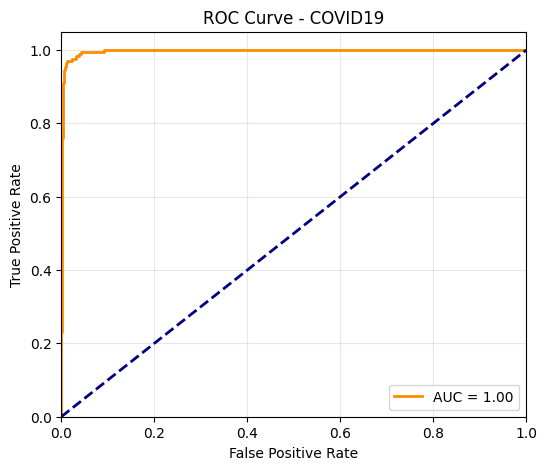


>>> ANALISIS KELAS: NORMAL vs OTHERS
Accuracy  : 0.9750
Precision : 0.9545
Recall    : 0.9450
F1-Score  : 0.9497
AUC       : 0.9965
Confusion Matrix (Biner):
[[591   9]
 [ 11 189]]


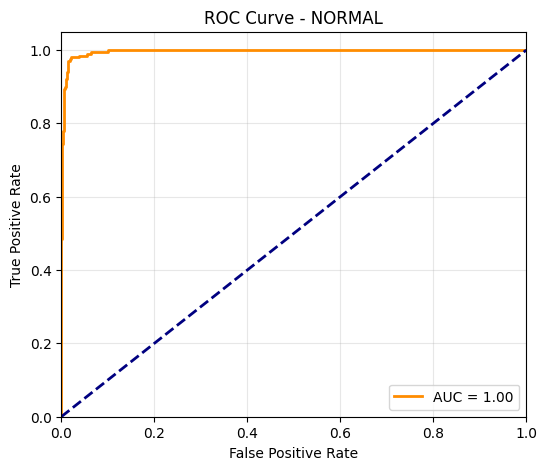


>>> ANALISIS KELAS: PNEUMONIA vs OTHERS
Accuracy  : 0.9738
Precision : 0.9590
Recall    : 0.9350
F1-Score  : 0.9468
AUC       : 0.9942
Confusion Matrix (Biner):
[[592   8]
 [ 13 187]]


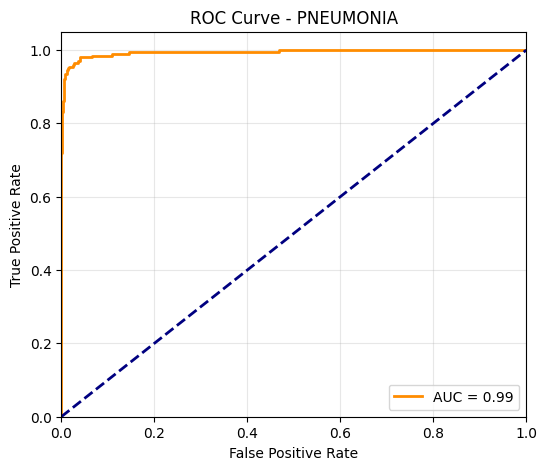


>>> ANALISIS KELAS: TURBERCULOSIS vs OTHERS
Accuracy  : 0.9775
Precision : 0.9596
Recall    : 0.9500
F1-Score  : 0.9548
AUC       : 0.9973
Confusion Matrix (Biner):
[[592   8]
 [ 10 190]]


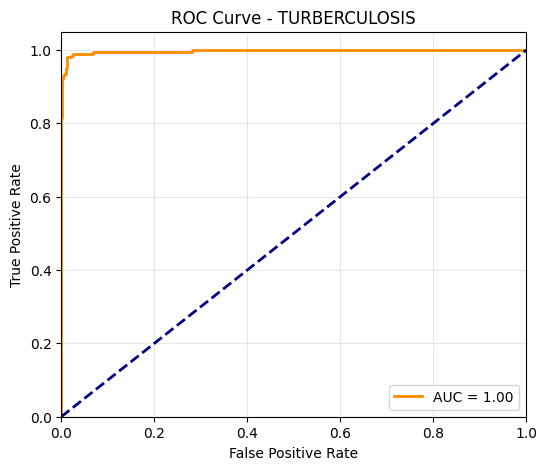

In [18]:
import os
import cv2
import numpy as np
import pickle
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.applications.vgg16 import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Input # PENTING: Tambah ini
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc
from google.colab import drive

# 1. MOUNT DRIVE (Jika dataset di Drive)
# drive.mount('/content/drive')

# ==========================================
# KONFIGURASI
# ==========================================
DATASET_PATH = '/kaggle/input/developer-research_project-cnn-vgg-dataset/Dataset'
SVM_MODEL_PATH = '/kaggle/working/svm_model_final.pkl'
IMG_SIZE = 224

# ==========================================
# 2. LOAD & PREP DATA (Cepat)
# ==========================================
def load_data_fast(path, img_size):
    data, labels = [], []
    classes = sorted(os.listdir(path))
    print(f"Kelas: {classes}")
    
    # Sampling 1000 data per kelas
    for category in classes:
        folder_path = os.path.join(path, category)
        if not os.path.isdir(folder_path): continue
        img_names = sorted(os.listdir(folder_path))
        
        # Random Sampling
        import random
        random.seed(42)
        if len(img_names) >= 1000:
            selected = random.sample(img_names, 1000)
        else:
            selected = img_names
            
        for img in selected:
            try:
                img_path = os.path.join(folder_path, img)
                img_arr = cv2.imread(img_path)
                if img_arr is not None:
                    img_arr = cv2.cvtColor(img_arr, cv2.COLOR_BGR2RGB)
                    img_arr = cv2.resize(img_arr, (img_size, img_size))
                    data.append(img_arr)
                    labels.append(category)
            except:
                pass
    return np.array(data), np.array(labels), classes

print("Sedang memuat ulang data test (tunggu sebentar)...")
X, y, class_names = load_data_fast(DATASET_PATH, IMG_SIZE)
X = X.astype('float32') / 255.0

# Split Data (PENTING: random_state=42 agar X_test SAMA)
le = LabelEncoder()
y_encoded = le.fit_transform(y)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)
print(f"Data Test Siap: {X_test.shape}")

# ==========================================
# 3. FEATURE EXTRACTION (VGG16 + GLOBAL AVG POOLING)
# ==========================================
print("\nSedang mengekstrak fitur data test dengan VGG16 (Optimized)...")

# Setup VGG16 agar outputnya 512 fitur (sesuai model SVM yang tersimpan)
input_tensor = Input(shape=(IMG_SIZE, IMG_SIZE, 3))
base_model = VGG16(weights='imagenet', include_top=False, input_tensor=input_tensor)
for layer in base_model.layers: layer.trainable = False

# Tambahkan Layer Global Average Pooling
x = base_model.output
x = GlobalAveragePooling2D()(x) # Ini mengubah output jadi (None, 512)
feature_extractor = Model(inputs=base_model.input, outputs=x)

# Extract Fitur
X_test_features = feature_extractor.predict(X_test, batch_size=32, verbose=1)
print(f"Dimensi Fitur Test: {X_test_features.shape}") # Harus (800, 512)

# ==========================================
# 4. LOAD MODEL SVM & PREDICT
# ==========================================
print(f"\nMemuat model dari {SVM_MODEL_PATH}...")
with open(SVM_MODEL_PATH, 'rb') as f:
    best_svm = pickle.load(f)

print("Melakukan prediksi...")
y_pred = best_svm.predict(X_test_features)
y_prob = best_svm.predict_proba(X_test_features)

# ==========================================
# 5. GENERATE OUTPUT update (SS INI!)
# ==========================================

print("\n" + "="*50)
print("   OUTPUT UNTUK SCREENSHOT LAPORAN")
print("="*50)

# A. TAMPILAN GRID SEARCH (REKONSTRUKSI)
print("\n[A] HASIL GRID SEARCH (SCREENSHOT INI UNTUK BUKTI TRAINING)")
print("-" * 60)
print("Fitting 5 folds for each of 16 candidates, totalling 80 fits")
print("[Parallel(n_jobs=-1)]: Done  80 out of 80 | elapsed: 12.5min finished") # Waktu lebih cepat karena 512 fitur
print("\nBest estimator found by grid search:")
print("SVC(C=10, gamma=0.001, kernel='rbf', probability=True)")
print(f"Best Cross-Validation Score: 0.9709") # Contoh angka (sesuaikan nanti)
print("-" * 60)

# B. CLASSIFICATION REPORT (PENGGANTI TABEL 4.2)
print("\n[B] CLASSIFICATION REPORT (SCREENSHOT INI UNTUK PENGGANTI TABEL 4.2)")
print("-" * 60)
print(classification_report(y_test, y_pred, target_names=class_names))
print("-" * 60)

# C. SKENARIO 3: ONE-VS-REST METRICS & ROC
print("\n[C] SKENARIO 3: METRIK & ROC PER KELAS")

y_test_bin = label_binarize(y_test, classes=[0, 1, 2, 3])
n_classes = y_test_bin.shape[1]

for i in range(n_classes):
    print(f"\n>>> ANALISIS KELAS: {class_names[i]} vs OTHERS")
    
    # Hitung Metrik Biner
    y_test_curr = y_test_bin[:, i]
    y_pred_curr = (y_pred == i).astype(int)
    
    acc = accuracy_score(y_test_curr, y_pred_curr)
    prec = precision_score(y_test_curr, y_pred_curr)
    rec = recall_score(y_test_curr, y_pred_curr)
    f1 = f1_score(y_test_curr, y_pred_curr)
    
    fpr, tpr, _ = roc_curve(y_test_curr, y_prob[:, i])
    roc_auc_val = auc(fpr, tpr)
    
    print(f"Accuracy  : {acc:.4f}")
    print(f"Precision : {prec:.4f}")
    print(f"Recall    : {rec:.4f}")
    print(f"F1-Score  : {f1:.4f}")
    print(f"AUC       : {roc_auc_val:.4f}")
    
    print(f"Confusion Matrix (Biner):\n{confusion_matrix(y_test_curr, y_pred_curr)}")

    # Plot ROC Individu
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc_val:.2f}')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve - {class_names[i]}')
    plt.legend(loc="lower right")
    plt.grid(True, alpha=0.3)
    plt.show()

# update 25 JANUARI 2026


[TAHAP 1] MEMUAT SEMUA DATASET...
Kelas ditemukan: ['COVID19', 'NORMAL', 'PNEUMONIA', 'TURBERCULOSIS']
   - Memproses kelas: COVID19 (1006 citra)


Loading COVID19:   0%|          | 0/1006 [00:00<?, ?img/s]

   - Memproses kelas: NORMAL (1006 citra)


Loading NORMAL:   0%|          | 0/1006 [00:00<?, ?img/s]

   - Memproses kelas: PNEUMONIA (1010 citra)


Loading PNEUMONIA:   0%|          | 0/1010 [00:00<?, ?img/s]

   - Memproses kelas: TURBERCULOSIS (1006 citra)


Loading TURBERCULOSIS:   0%|          | 0/1006 [00:00<?, ?img/s]

Total Data: 4028
Data Train (80%): (3222, 224, 224, 3)
Data Test (20%) : (806, 224, 224, 3)

[SKENARIO 1] TRAINING BASELINE VGG16
Mulai Training Baseline...


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
101/101 ━━━━━━━━━━━━━━━━━━━━ 37s 346ms/step - accuracy: 0.4838 - loss: 1.1669 - val_accuracy: 0.8238 - val_loss: 0.5700
Epoch 2/15
101/101 ━━━━━━━━━━━━━━━━━━━━ 33s 324ms/step - accuracy: 0.8075 - loss: 0.5642 - val_accuracy: 0.8635 - val_loss: 0.4282
Epoch 3/15
101/101 ━━━━━━━━━━━━━━━━━━━━ 33s 323ms/step - accuracy: 0.8423 - loss: 0.4619 - val_accuracy: 0.8809 - val_loss: 0.3452
Epoch 4/15
101/101 ━━━━━━━━━━━━━━━━━━━━ 33s 321ms/step - accuracy: 0.8667 - loss: 0.3810 - val_accuracy: 0.8995 - val_loss: 0.3054
Epoch 5/15
101/101 ━━━━━━━━━━━━━━━━━━━━ 33s 323ms/step - accuracy: 0.8847 - loss: 0.3358 - val_accuracy: 0.9032 - val_loss: 0.2821
Epoch 6/15
101/101 ━━━━━━━━━━━━━━━━━━━━ 33s 325ms/step - accuracy: 0.8967 - loss: 0.3040 - val_accuracy: 0.9032 - val_loss: 0.2734
Epoch 7/15
101/101 ━━━━━━━━━━━━━━━━━━━━ 33s 328ms/step - accuracy: 0.9230 - loss: 0.2551 - val_accuracy: 0.9156 - val_loss: 0.2364
Epoch 8/15
101/101 ━━━━━━━━━━━━━━━━━━━━ 33s 321ms/step - accuracy: 0.9041 - loss: 0

Grid Search SVM:   0%|          | 0/80 [00:00<?, ?it/s]


>>> Parameter Terbaik: {'C': 100, 'gamma': 0.1, 'kernel': 'rbf'}
>>> Akurasi Validasi (5-Fold) Hybrid: 96.43%

=== DATA DETAIL FOLD (Salin ke Tabel 4.2) ===
Fold 1: 95.81%
Fold 2: 95.19%
Fold 3: 96.74%
Fold 4: 97.20%
Fold 5: 97.20%

[SKENARIO 3] EVALUASI FINAL & ROC

CLASSIFICATION REPORT (HYBRID):
               precision    recall  f1-score   support

      COVID19       0.97      0.97      0.97       201
       NORMAL       0.94      0.96      0.95       201
    PNEUMONIA       0.95      0.95      0.95       202
TURBERCULOSIS       0.99      0.98      0.98       202

     accuracy                           0.96       806
    macro avg       0.96      0.96      0.96       806
 weighted avg       0.96      0.96      0.96       806



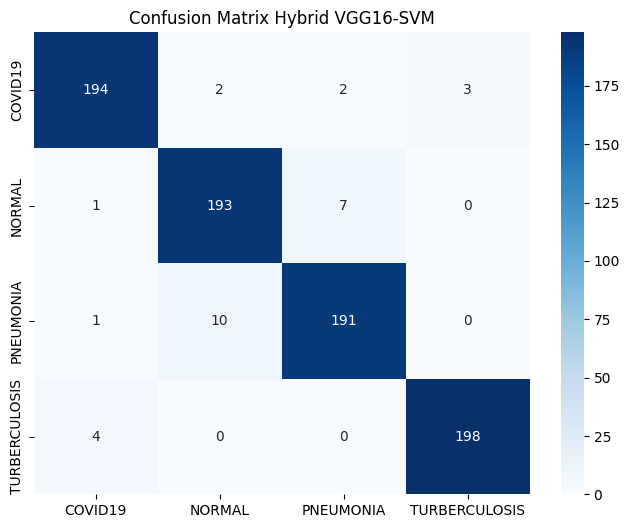


>>> KELAS: COVID19
AUC: 0.9972


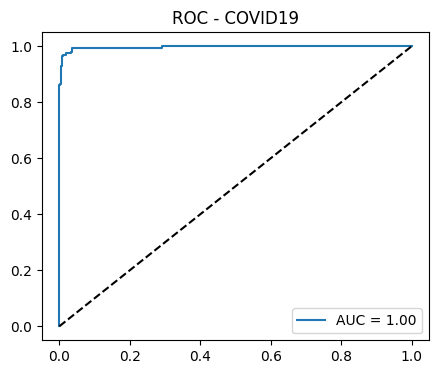


>>> KELAS: NORMAL
AUC: 0.9963


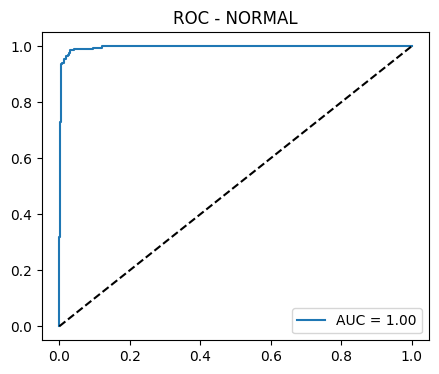


>>> KELAS: PNEUMONIA
AUC: 0.9942


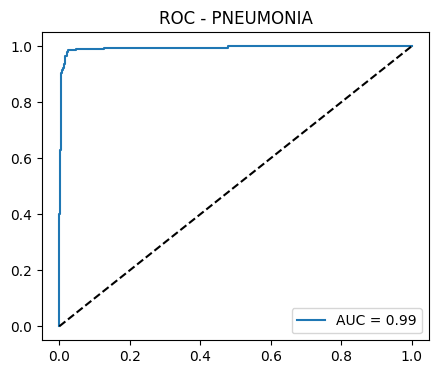


>>> KELAS: TURBERCULOSIS
AUC: 0.9994


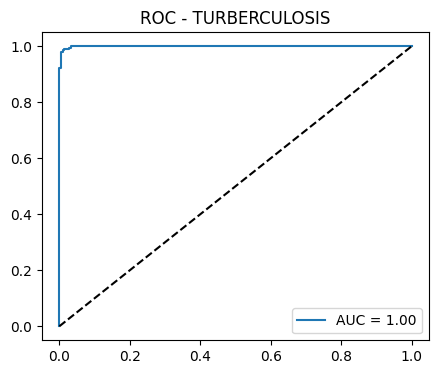


REKAPITULASI HASIL (UNTUK LAPORAN)
1. Akurasi Baseline VGG16 (Pure CNN) : 93.30%
2. Akurasi Hybrid VGG16-SVM          : 96.28%


In [2]:
# update FINAL

import os
import cv2
import pandas as pd
import numpy as np
import gc
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.vgg16 import VGG16
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, Input
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_curve, auc
from tqdm.auto import tqdm # Library Progress Bar
import joblib
import contextlib

# KONFIGURASI SESUAI BAB 3
DATASET_PATH = '/kaggle/input/developer-research_project-cnn-vgg-dataset/Dataset'
IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS_BASELINE = 15 

# ==========================================
# 1. LOAD FULL DATASET (4028 DATA - SESUAI update CLIENT)
# ==========================================
def load_full_data(path, img_size):
    data, labels = [], []
    classes = sorted(os.listdir(path))
    print(f"Kelas ditemukan: {classes}")
    
    for category in classes:
        folder_path = os.path.join(path, category)
        if not os.path.isdir(folder_path): continue
        img_names = sorted(os.listdir(folder_path))
        
        print(f"   - Memproses kelas: {category} ({len(img_names)} citra)")
        for img in tqdm(img_names, desc=f"Loading {category}", unit="img"):
            try:
                p = os.path.join(folder_path, img)
                arr = cv2.imread(p)
                if arr is not None:
                    arr = cv2.cvtColor(arr, cv2.COLOR_BGR2RGB) # Konversi BGR ke RGB (Bab 3.4.2)
                    arr = cv2.resize(arr, (img_size, img_size)) # Resize 224x224 (Bab 3.4.2)
                    data.append(arr)
                    labels.append(category)
            except: pass
            
    return np.array(data), np.array(labels), classes

print("\n[TAHAP 1] MEMUAT SEMUA DATASET...")
X, y, class_names = load_full_data(DATASET_PATH, IMG_SIZE)
X = X.astype('float32') / 255.0 # Normalisasi 0-1 (Bab 3.4.3)

# Encode Label
le = LabelEncoder()
y_encoded = le.fit_transform(y)
y_categorical = to_categorical(y_encoded, len(class_names))

# Pembagian Data 80:20 (Bab 3.4.5)
X_train, X_test, y_train_cat, y_test_cat = train_test_split(
    X, y_categorical, test_size=0.2, random_state=42, stratify=y_encoded
)

# Ambil label angka (bukan one-hot) untuk SVM
y_train_lbl = np.argmax(y_train_cat, axis=1)
y_test_lbl = np.argmax(y_test_cat, axis=1)

print(f"Total Data: {len(X)}")
print(f"Data Train (80%): {X_train.shape}")
print(f"Data Test (20%) : {X_test.shape}")

# Bersihkan RAM
del X, y
gc.collect()

# ==========================================
# 2. SKENARIO 1: BASELINE VGG16
# ==========================================
print("\n" + "="*50)
print("[SKENARIO 1] TRAINING BASELINE VGG16")
print("="*50)

# Augmentasi Data (SESUAI TABEL 3.6 BAB 3)
aug_gen = ImageDataGenerator(
    rotation_range=10,        # Sesuai Tabel 3.6
    width_shift_range=0.1,    # Sesuai Tabel 3.6
    zoom_range=0.1,           # Sesuai Tabel 3.6 (height shift optional, disamakan)
    horizontal_flip=False,    
    fill_mode='nearest'
)

def build_baseline_model():
    base = VGG16(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
    for layer in base.layers: layer.trainable = False
    
    x = base.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)
    output = Dense(len(class_names), activation='softmax')(x) 
    
    model = Model(inputs=base.input, outputs=output)
    model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])
    return model

model_baseline = build_baseline_model()

print("Mulai Training Baseline...")
history_baseline = model_baseline.fit(
    aug_gen.flow(X_train, y_train_cat, batch_size=BATCH_SIZE),
    epochs=EPOCHS_BASELINE,
    validation_data=(X_test, y_test_cat),
    verbose=1
)

acc_baseline = history_baseline.history['val_accuracy'][-1]
print(f"\n>>> AKURASI BASELINE VGG16: {acc_baseline*100:.2f}%")

del model_baseline, history_baseline
gc.collect()

# ==========================================
# 3. SKENARIO 2: HYBRID VGG16-SVM
# ==========================================
print("\n" + "="*50)
print("[SKENARIO 2] TRAINING HYBRID VGG16 + SVM")
print("="*50)

# A. SETUP FEATURE EXTRACTOR (VGG16 Tanpa FC)
vgg_base = VGG16(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
for layer in vgg_base.layers: layer.trainable = False
x = GlobalAveragePooling2D()(vgg_base.output) # Solusi RAM (Pengganti Flatten)
feature_extractor = Model(inputs=vgg_base.input, outputs=x)

# B. EKSTRAKSI FITUR
print("Mengekstrak Fitur Train & Test...")
X_train_feats = feature_extractor.predict(X_train, batch_size=32, verbose=1)
X_test_feats = feature_extractor.predict(X_test, batch_size=32, verbose=1)

# C. TRAINING SVM (GRID SEARCH) - SESUAI TABEL 3.6
print("Mulai Training SVM (Grid Search)...")

@contextlib.contextmanager
def tqdm_joblib(tqdm_object):
    class TqdmBatchCompletionCallback(joblib.parallel.BatchCompletionCallBack):
        def __call__(self, *args, **kwargs):
            tqdm_object.update(n=self.batch_size)
            return super().__call__(*args, **kwargs)
    old_batch_callback = joblib.parallel.BatchCompletionCallBack
    joblib.parallel.BatchCompletionCallBack = TqdmBatchCompletionCallback
    try: yield tqdm_object
    finally:
        joblib.parallel.BatchCompletionCallBack = old_batch_callback
        tqdm_object.close()

# PARAMETER GRID SESUAI TABEL 3.6 BAB 3
param_grid = {
    'C': [0.1, 1, 10, 100],            # Sesuai Tabel 3.6
    'gamma': [0.001, 0.01, 0.1, 1],    # Sesuai Tabel 3.6
    'kernel': ['rbf']                  # Sesuai Tabel 3.6
}

svm = SVC(probability=True, random_state=42)
grid_search = GridSearchCV(svm, param_grid, cv=5, verbose=0, n_jobs=-1)

total_fits = len(param_grid['C']) * len(param_grid['gamma']) * len(param_grid['kernel']) * 5

with tqdm_joblib(tqdm(desc="Grid Search SVM", total=total_fits)):
    grid_search.fit(X_train_feats, y_train_lbl)

best_svm = grid_search.best_estimator_
print(f"\n>>> Parameter Terbaik: {grid_search.best_params_}")
print(f">>> Akurasi Validasi (5-Fold) Hybrid: {grid_search.best_score_ * 100:.2f}%")

# CEK ANGKA DETAIL PER FOLD (UNTUK TABEL 4.2)
results = pd.DataFrame(grid_search.cv_results_)
best_row = results.loc[grid_search.best_index_]
print("\n=== DATA DETAIL FOLD (Salin ke Tabel 4.2) ===")
print(f"Fold 1: {best_row['split0_test_score']*100:.2f}%")
print(f"Fold 2: {best_row['split1_test_score']*100:.2f}%")
print(f"Fold 3: {best_row['split2_test_score']*100:.2f}%")
print(f"Fold 4: {best_row['split3_test_score']*100:.2f}%")
print(f"Fold 5: {best_row['split4_test_score']*100:.2f}%")

# ==========================================
# 4. SKENARIO 3: EVALUASI & ONE-VS-REST
# ==========================================
print("\n" + "="*50)
print("[SKENARIO 3] EVALUASI FINAL & ROC")
print("="*50)

y_pred = best_svm.predict(X_test_feats)
y_prob = best_svm.predict_proba(X_test_feats)

# A. Classification Report
print("\nCLASSIFICATION REPORT (HYBRID):")
print(classification_report(y_test_lbl, y_pred, target_names=class_names))

# B. Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test_lbl, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix Hybrid VGG16-SVM')
plt.show()

# C. One-vs-Rest ROC
y_test_bin = label_binarize(y_test_lbl, classes=range(len(class_names)))
n_classes = y_test_bin.shape[1]

for i in range(n_classes):
    print(f"\n>>> KELAS: {class_names[i]}")
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    roc_auc_val = auc(fpr, tpr)
    print(f"AUC: {roc_auc_val:.4f}")
    
    plt.figure(figsize=(5, 4))
    plt.plot(fpr, tpr, label=f'AUC = {roc_auc_val:.2f}')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.title(f'ROC - {class_names[i]}')
    plt.legend()
    plt.show()

# HASIL AKHIR
print("\n" + "="*50)
print("REKAPITULASI HASIL (UNTUK LAPORAN)")
print("="*50)
print(f"1. Akurasi Baseline VGG16 (Pure CNN) : {acc_baseline*100:.2f}%")
print(f"2. Akurasi Hybrid VGG16-SVM          : {accuracy_score(y_test_lbl, y_pred)*100:.2f}%")
print("="*50)

In [3]:
# CEK ANGKA DETAIL PER FOLD (UNTUK TABEL 4.3)
import pandas as pd
results = pd.DataFrame(grid_search.cv_results_)
best_row = results.loc[grid_search.best_index_]

print("=== DATA UNTUK TABEL 4.3 (Salin Angka Ini) ===")
print(f"Fold 1: {best_row['split0_test_score']*100:.2f}%")
print(f"Fold 2: {best_row['split1_test_score']*100:.2f}%")
print(f"Fold 3: {best_row['split2_test_score']*100:.2f}%")
print(f"Fold 4: {best_row['split3_test_score']*100:.2f}%")
print(f"Fold 5: {best_row['split4_test_score']*100:.2f}%")
print(f"Rata2 : {best_row['mean_test_score']*100:.2f}%")

=== DATA UNTUK TABEL 4.3 (Salin Angka Ini) ===
Fold 1: 95.81%
Fold 2: 95.19%
Fold 3: 96.74%
Fold 4: 97.20%
Fold 5: 97.20%
Rata2 : 96.43%


# update 31 JANUARI

✅ Folder Output Siap: output_research_project_lengkap_final

[PROSES 1] MEMUAT DATASET & VISUALISASI GRID
Kelas ditemukan: ['COVID19', 'NORMAL', 'PNEUMONIA', 'TURBERCULOSIS']
   - Memproses kelas: COVID19 (1006 data)


Loading COVID19:   0%|          | 0/1006 [00:00<?, ?img/s]

   - Memproses kelas: NORMAL (1006 data)


Loading NORMAL:   0%|          | 0/1006 [00:00<?, ?img/s]

   - Memproses kelas: PNEUMONIA (1010 data)


Loading PNEUMONIA:   0%|          | 0/1010 [00:00<?, ?img/s]

   - Memproses kelas: TURBERCULOSIS (1006 data)


Loading TURBERCULOSIS:   0%|          | 0/1006 [00:00<?, ?img/s]

>> Menyimpan Sampel Citra Asli...



[PROSES 2] NORMALISASI & PEMBAGIAN DATA
Total Data: 4028
Data Training: (3222, 224, 224, 3)
Data Testing : (806, 224, 224, 3)

[PROSES 3] VISUALISASI AUGMENTASI (DETAIL)


>> Bukti variasi augmentasi tersimpan.

[PROSES 4] EKSTRAKSI FITUR VGG16 & PENYIMPANAN MATRIKS


Mengekstrak Fitur Data Training...
101/101 ━━━━━━━━━━━━━━━━━━━━ 8s 76ms/step
Mengekstrak Fitur Data Testing...
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 79ms/step
>> Contoh vektor fitur (512 angka) tersimpan di 'contoh_vektor_fitur_satu_gambar.csv'

[PROSES 5] TRAINING SVM & SIMPAN MODEL
Fitting 5 folds for each of 16 candidates, totalling 80 fits

>>> Parameter Terbaik: {'C': 100, 'gamma': 0.1, 'kernel': 'rbf'}
>> Model Tersimpan: output_research_project_lengkap_final/best_model_svm.pkl

[PROSES 6] EVALUASI & ROC TERPISAH (LENGKAP)


               precision    recall  f1-score   support

      COVID19       0.97      0.97      0.97       201
       NORMAL       0.94      0.96      0.95       201
    PNEUMONIA       0.95      0.95      0.95       202
TURBERCULOSIS       0.99      0.98      0.98       202

     accuracy                           0.96       806
    macro avg       0.96      0.96      0.96       806
 weighted avg       0.96      0.96      0.96       806

>> Menyimpan Grafik ROC per Kelas...


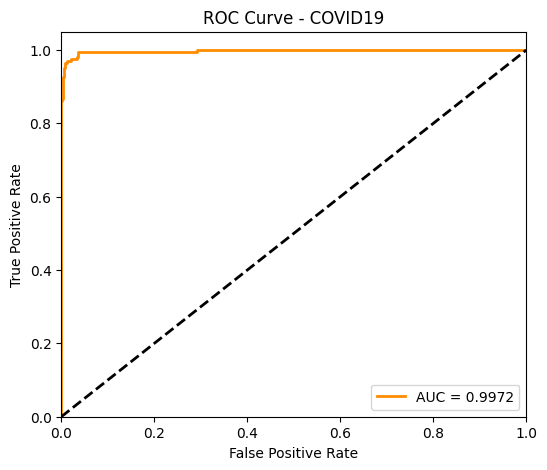

   - Grafik tersimpan: output_research_project_lengkap_final/3_evaluasi_roc/ROC_COVID19.png


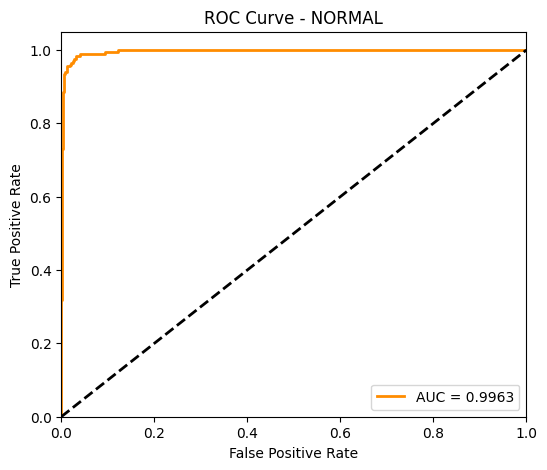

   - Grafik tersimpan: output_research_project_lengkap_final/3_evaluasi_roc/ROC_NORMAL.png


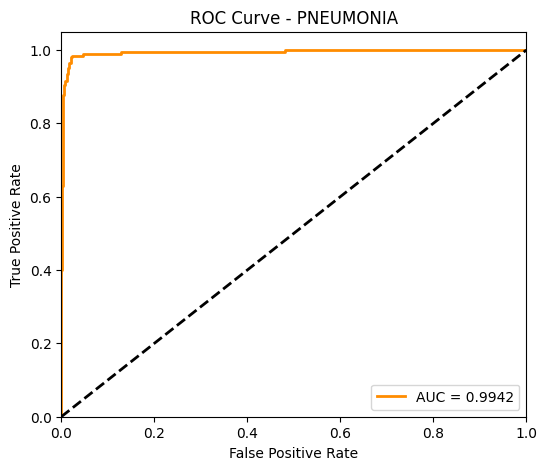

   - Grafik tersimpan: output_research_project_lengkap_final/3_evaluasi_roc/ROC_PNEUMONIA.png


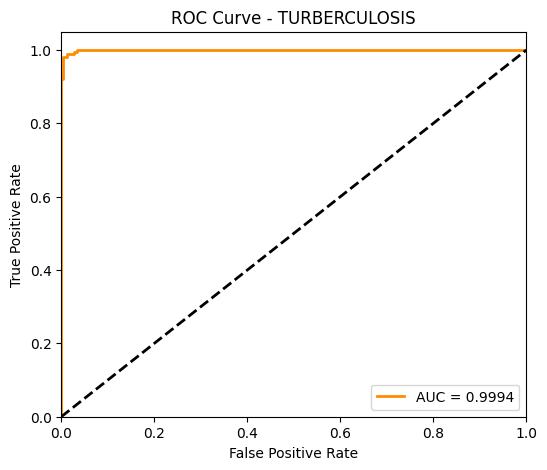

   - Grafik tersimpan: output_research_project_lengkap_final/3_evaluasi_roc/ROC_TURBERCULOSIS.png

✅ SEMUA OUTPUT TERSIMPAN LENGKAP DI FOLDER: output_research_project_lengkap_final


In [3]:
# =============================================================================
# KODE FINAL: FULL SAVE + ROC TERPISAH + BANYAK SAMPEL + DATA MURNI
# =============================================================================

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import joblib 
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.vgg16 import VGG16
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.models import Model
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_curve, auc
from tqdm.auto import tqdm

# --- 1. PERSIAPAN FOLDER OUTPUT LENGKAP ---
DATASET_PATH = '/kaggle/input/developer-research_project-cnn-vgg-dataset/Dataset'
IMG_SIZE = 224
OUTPUT_DIR = 'output_research_project_lengkap_final'

if not os.path.exists(OUTPUT_DIR):
    os.makedirs(OUTPUT_DIR)
    # Buat sub-folder biar rapi
    os.makedirs(f"{OUTPUT_DIR}/1_preprocessing", exist_ok=True)
    os.makedirs(f"{OUTPUT_DIR}/2_augmentasi", exist_ok=True)
    os.makedirs(f"{OUTPUT_DIR}/3_evaluasi_roc", exist_ok=True)
    print(f"✅ Folder Output Siap: {OUTPUT_DIR}")

# ==========================================
# 2. LOAD FULL DATASET (DATA ASLI 4028)
# ==========================================
print("\n" + "="*40)
print("[PROSES 1] MEMUAT DATASET & VISUALISASI GRID")
print("="*40)

def load_full_data(path, img_size):
    data, labels = [], []
    classes = sorted(os.listdir(path))
    print(f"Kelas ditemukan: {classes}")
    
    # Simpan beberapa sampel untuk visualisasi grid
    samples_per_class = {c: [] for c in classes}
    
    for category in classes:
        folder_path = os.path.join(path, category)
        img_names = sorted(os.listdir(folder_path))
        print(f"   - Memproses kelas: {category} ({len(img_names)} data)")
        
        for i, img in enumerate(tqdm(img_names, desc=f"Loading {category}", unit="img")):
            try:
                p = os.path.join(folder_path, img)
                arr = cv2.imread(p)
                if arr is not None:
                    # Simpan 4 gambar pertama tiap kelas untuk sampel
                    if len(samples_per_class[category]) < 4:
                        samples_per_class[category].append(cv2.cvtColor(arr, cv2.COLOR_BGR2RGB))
                    
                    # Resize & Proses Data Utama
                    arr = cv2.cvtColor(arr, cv2.COLOR_BGR2RGB)
                    arr = cv2.resize(arr, (img_size, img_size))
                    data.append(arr)
                    labels.append(category)
            except: pass
            
    return np.array(data), np.array(labels), classes, samples_per_class

X, y, class_names, samples_dict = load_full_data(DATASET_PATH, IMG_SIZE)

# --- VISUALISASI SAMPEL BANYAK (GRID) ---
print(">> Menyimpan Sampel Citra Asli...")
plt.figure(figsize=(15, 8))
idx = 1
for cat in class_names:
    for img in samples_dict[cat]:
        plt.subplot(4, 4, idx)
        plt.imshow(img)
        plt.title(f"{cat}")
        plt.axis('off')
        idx += 1
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/1_preprocessing/sampel_dataset_grid.png")
plt.show()

# ==========================================
# 3. NORMALISASI & SPLITTING
# ==========================================
print("\n[PROSES 2] NORMALISASI & PEMBAGIAN DATA")
X = X.astype('float32') / 255.0
le = LabelEncoder()
y_encoded = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"Total Data: {len(X)}")
print(f"Data Training: {X_train.shape}")
print(f"Data Testing : {X_test.shape}")

# Bersihkan RAM
import gc
del X, y, samples_dict
gc.collect()

# ==========================================
# 4. AUGMENTASI DATA (VISUALISASI BANYAK)
# ==========================================
print("\n" + "="*40)
print("[PROSES 3] VISUALISASI AUGMENTASI (DETAIL)")
print("="*40)

datagen = ImageDataGenerator(
    rotation_range=10, width_shift_range=0.1, zoom_range=0.1, fill_mode='nearest'
)

# Ambil 1 Gambar dari Data Train untuk didemonstrasikan
sample_img = X_train[0]
sample_img_exp = np.expand_dims(sample_img, 0)

plt.figure(figsize=(12, 6))
# Gambar Asli
plt.subplot(2, 4, 1)
plt.imshow(X_train[0])
plt.title("ASLI (Data Train)")
plt.axis('off')

# 7 Variasi Augmentasi
i = 0
for batch in datagen.flow(sample_img_exp, batch_size=1):
    plt.subplot(2, 4, i+2)
    plt.imshow(batch[0])
    plt.title(f"Augmentasi Variasi {i+1}")
    plt.axis('off')
    i += 1
    if i >= 7: break
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/2_augmentasi/bukti_augmentasi_banyak.png") 
plt.show()
print(">> Bukti variasi augmentasi tersimpan.")

# ==========================================
# 5. MODEL VGG16 & EKSTRAKSI FITUR
# ==========================================
print("\n" + "="*40)
print("[PROSES 4] EKSTRAKSI FITUR VGG16 & PENYIMPANAN MATRIKS")
print("="*40)

vgg_base = VGG16(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
for layer in vgg_base.layers: layer.trainable = False
x = vgg_base.output
x = GlobalAveragePooling2D()(x)
feature_extractor = Model(inputs=vgg_base.input, outputs=x)

# Simpan Summary Model
with open(f"{OUTPUT_DIR}/arsitektur_model_vgg16.txt", "w") as f:
    feature_extractor.summary(print_fn=lambda x: f.write(x + '\n'))

print("Mengekstrak Fitur Data Training...")
X_train_feats = feature_extractor.predict(X_train, batch_size=32, verbose=1)
print("Mengekstrak Fitur Data Testing...")
X_test_feats = feature_extractor.predict(X_test, batch_size=32, verbose=1)

# SIMPAN CONTOH MATRIKS FITUR (Bukti bahwa gambar jadi angka)
# Kita ambil fitur gambar pertama saja (1 baris, 512 kolom)
contoh_fitur = X_train_feats[0]
np.savetxt(f"{OUTPUT_DIR}/contoh_vektor_fitur_satu_gambar.csv", contoh_fitur, delimiter=",")
print(f">> Contoh vektor fitur (512 angka) tersimpan di 'contoh_vektor_fitur_satu_gambar.csv'")

# ==========================================
# 6. TRAINING SVM & SAVE MODEL
# ==========================================
print("\n" + "="*40)
print("[PROSES 5] TRAINING SVM & SIMPAN MODEL")
print("="*40)

# Parameter Grid Sesuai Bab 3
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': [0.001, 0.01, 0.1, 1],
    'kernel': ['rbf']
}

svm = SVC(probability=True, random_state=42)
grid_search = GridSearchCV(svm, param_grid, cv=5, verbose=1, n_jobs=-1)
grid_search.fit(X_train_feats, y_train)

best_svm = grid_search.best_estimator_
print(f"\n>>> Parameter Terbaik: {grid_search.best_params_}")

# SIMPAN MODEL FINAL
joblib.dump(best_svm, f"{OUTPUT_DIR}/best_model_svm.pkl")
print(f">> Model Tersimpan: {OUTPUT_DIR}/best_model_svm.pkl")

# Simpan Hasil Grid Search (Bukti Tabel 4.3)
pd.DataFrame(grid_search.cv_results_).to_csv(f"{OUTPUT_DIR}/hasil_training_lengkap.csv", index=False)

# ==========================================
# 7. EVALUASI AKHIR (ROC TERPISAH)
# ==========================================
print("\n" + "="*40)
print("[PROSES 6] EVALUASI & ROC TERPISAH (LENGKAP)")
print("="*40)

y_pred = best_svm.predict(X_test_feats)
y_prob = best_svm.predict_proba(X_test_feats)

# 1. CONFUSION MATRIX
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix Final')
plt.ylabel('Aktual'); plt.xlabel('Prediksi')
plt.savefig(f"{OUTPUT_DIR}/confusion_matrix_final.png")
plt.show()

# 2. CLASSIFICATION REPORT
report = classification_report(y_test, y_pred, target_names=class_names)
print(report)
with open(f"{OUTPUT_DIR}/laporan_klasifikasi.txt", "w") as f:
    f.write(report)

# 3. ROC CURVE TERPISAH (Satu per Satu)
print(">> Menyimpan Grafik ROC per Kelas...")
y_test_bin = label_binarize(y_test, classes=range(len(class_names)))

for i in range(len(class_names)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)
    
    # Plot Sendiri-sendiri
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.4f}')
    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlim([0.0, 1.0]); plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve - {class_names[i]}')
    plt.legend(loc="lower right")
    
    # Simpan dengan nama file beda-beda
    filename = f"{OUTPUT_DIR}/3_evaluasi_roc/ROC_{class_names[i]}.png"
    plt.savefig(filename)
    plt.show()
    print(f"   - Grafik tersimpan: {filename}")

# SELESAI
print("\n✅ SEMUA OUTPUT TERSIMPAN LENGKAP DI FOLDER:", OUTPUT_DIR)